# EmporiUm Business Sales Analysis
## Sale Territories and Manager

- Florida- Lana Llana.
- Maine- Erbayne Middleton.
  
 This project focuses on analyzing business sales data for EmporiUm using Python and Jupyter Notebook. EmporiUm is a growing bookstore company that also sells technology products, art supplies, and other merchandise through both in-store and online sales channels.

 In this project, I will import, clean, and analyze sales data to better understand business performance in my assigned territories. I will examine monthly revenue trends, compare store performance, identify top customers, review product category sales, and create charts using Matplotlib to visualize my findings. Based on the results of my analysis, I will also provide recommendations on where marketing efforts should be focused for the next quarter.

## Importing libraries 

In [1]:
# import brings tools into python 
# numpy is used marth operations and working with numbers
# pandas is used for reading and analyzing data tables
# matplotlib is used to create chart and visuals
# %matplotlib inline displays charts inthe notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

### Loading Customer List csv

In [2]:
# loading my csv file usind the pd.read_csv() and
# confirming column namesm, non-null and data type using info()
# pd.read_csv() reads a csv file into python
# df_customers is the variable that stores the customer table

# The customer file uses | as a seperator. so i use , sep='|' to make the data mor readable
# Customer_list csv
df_customers = pd.read_csv('customer_list.csv', sep='|')
df_customers.columns = df_customers.columns.str.strip()
df_customers.info()
df_customers.head()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cust_id      521 non-null    int64
 1   date         521 non-null    str  
 2   time         521 non-null    str  
 3   name         521 non-null    str  
 4   email        521 non-null    str  
 5   phone        520 non-null    str  
 6   sms-opt-out  520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


### Loading Product Categories csv

In [3]:
# Same for ProductCategoris csv

# df_categories stores product category info.
# it help connect product to categories and subcategories.
df_categories = pd.read_csv('ProductCategories.csv')
df_categories.info()
df_categories.head()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


### Loading Products csv

In [4]:
# This file will be merged with sales using product Num.
# Product Num is the shared colomn between sales and products
df_products = pd.read_csv('Products.csv')
df_products.info()
df_products.head()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


### Loading Store Detail csv

In [5]:
# df_stores keeps store location, state, store id, manager and regiongs.
# this file help to identify florida and Maine store

df_stores = pd.read_csv('storeDetail.csv')
df_stores.info()
df_stores.head()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


### Loading Store Sales Dcsv

In [6]:
# df_sales keeps store transaction level sale data.
# this includes informations like; transaction date, store id, rewords id, product number, and sale amount.
# this is the main table used for most of my analysis.
df_sales = pd.read_csv('StoreSales.csv')
df_sales.info()
df_sales.head()                       

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


# Core Marketing Analysis

### Data prep and cleaning

In [24]:
# pd.to_datetime() converts text dates into real dates.
# .dt.to_period("M") extracts the month.
# isin() filters matching territories.
# copy() makes a safe copy.

df_sales["Transaction Date"] = pd.to_datetime(
    df_sales["Transaction Date"]
)

df_sales["Sales Month"] = (
    df_sales["Transaction Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

territories = ["Florida", "Maine"]

assigned_stores = df_stores[
    df_stores["State"].isin(territories)
].copy()

assigned_stores
df_sales.head(3)

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Sales Month
0,2022-01-01,702,NaN,105349-M,8.0,2022-01-01
1,2022-01-01,704,NaN,105350-T,144.0,2022-01-01
2,2022-01-01,705,NaN,105351-M,44.0,2022-01-01


In [23]:
# merge() combines two DataFrames.
# on="Store ID" means both tables share Store ID.
# how="inner" keeps matching rows only.

sales_with_store = df_sales.merge(
    assigned_stores,
    on="Store ID",
    how="inner"
)

sales_with_store.head(3)

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Sales Month,Store Location,State,Territory Manager,Region,Region Director
0,2022-01-01,719,NaN,105376-M,44.50,2022-01-01,Cape Canaveral,Florida,Lana Ilana,South,Andy Gisselquist
1,2022-01-01,721,NaN,105310-IT,71.74,2022-01-01,Jacksonville,Florida,Lana Ilana,South,Andy Gisselquist
2,2022-01-01,723,NaN,105377-A,5.00,2022-01-01,Lakeland,Florida,Lana Ilana,South,Andy Gisselquist


## Question 1
Who are the territory managers for the assigned sales territories? What are the store IDs and cities for the stores in each territory?
To answer this question, I first need to identify the stores located in Florida and Maine.
### What I Am Looking For
- Territory manager names  
- Store IDs  
- Store cities and locations  
- Assigned regions for Florida and Maine

In [9]:
# [[ ]] = selects multiple columns.
# sort_values() = sorts rows.
# ["State","Store ID"] = sorting columns.
# reset_index() = resets row numbering.
# drop=True = removes old index

territory_managers_stores = assigned_stores[
    ["State", "Territory Manager", "Store ID", "Store Location", "Region"]
].sort_values(
    ["State", "Store ID"]
).reset_index(drop=True)

territory_managers_stores.head(3)

,State,Territory Manager,Store ID,Store Location,Region
0,Florida,Lana Ilana,719,Cape Canaveral,South
1,Florida,Lana Ilana,720,Fort Lauderdale,South
2,Florida,Lana Ilana,721,Jacksonville,South



### Question 2
What is monthly total revenue for in-store sales in each of the two sales territories over the full period covered by the data?
### logic
To answer this question, I first need to use the merge dataframe in data prep above so I can identify which transactions belong to Florida and Maine. Next, I will convert the transaction dates into monthly periods and calculate total revenue for each month.

### What I Am Looking For
- What is monthly total revenue for Florida
- over the full period covered by the data?


In [10]:
# groupby() = groups similar rows.
# ["State","Sales Month"] = grouping columns.
# as_index=False = keeps result as DataFrame.
# ["Sale Amount"] = selected column.
# sum() = adds values.
# rename() = changes column name.

monthly_revenue = sales_with_store.groupby(
    ["State", "Sales Month"],
    as_index=False
)["Sale Amount"].sum()

monthly_revenue = monthly_revenue.rename(
    columns={"Sale Amount": "Monthly Revenue"}
)

monthly_revenue = monthly_revenue.sort_values(
    ["State", "Sales Month"]
).reset_index(drop=True)

monthly_revenue.head(3)

,State,Sales Month,Monthly Revenue
0,Florida,2022-01-01,48143.95
1,Florida,2022-02-01,46257.35
2,Florida,2022-03-01,53541.25


### Chart for Monthly In-Store Revenue: Florida vs Maine

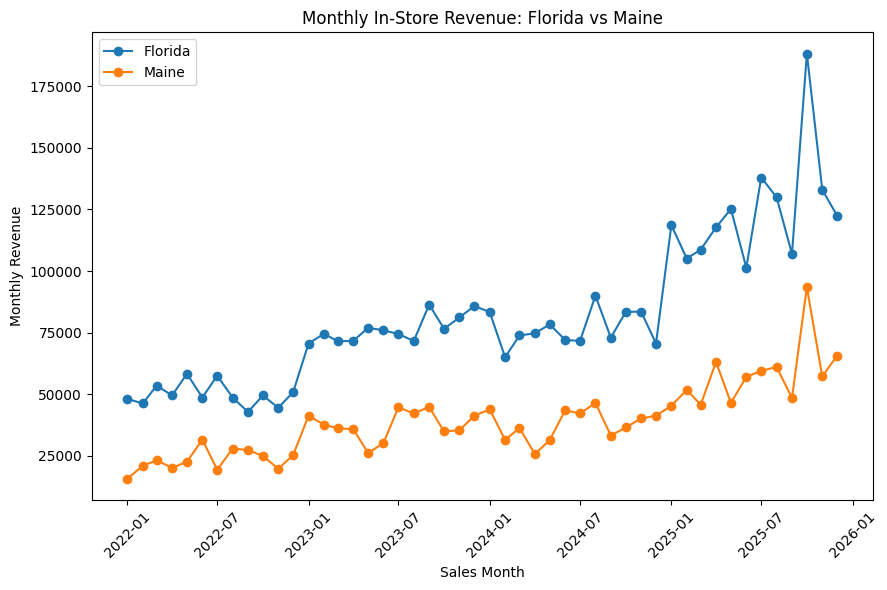

In [11]:

# plt.figure() = creates chart size.
# figsize=(12,6) = chart width and height.
# for = loops through Florida and Maine.
# plt.plot() = creates a line chart.
# marker="o" = adds dots on each point.
# label= = creates legend labels.
# plt.title() = chart title.
# plt.xlabel() = x-axis label.
# plt.ylabel() = y-axis label.
# plt.legend() = shows territory labels.
# plt.xticks(rotation=45) = rotates dates.
# plt.tight_layout() = improves spacing.
# plt.show() = displays the chart.

plt.figure(figsize=(9,6))

for state in territories:

    state_data = monthly_revenue[
        monthly_revenue["State"] == state
    ]

    plt.plot(
        state_data["Sales Month"],
        state_data["Monthly Revenue"],
        marker="o",
        label=state
    )

plt.title( "Monthly In-Store Revenue: Florida vs Maine")

plt.xlabel( "Sales Month")
plt.ylabel("Monthly Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart Interpretation

This line chart compares monthly in-store revenue between Florida and Maine over the full sales period. The x-axis represents Sales Month, while the y-axis represents Monthly Revenue.

The chart shows that Florida consistently generated higher monthly revenue than Maine throughout period. Florida’s revenue line (blue) stays above Maine line (orange), showing stronger overall store sales performance.

Both territories follow similar patterns of growth and decline over time. 

### Question 3
How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

### logc
To answer this question, I will group sales data by store and calculate total revenue for each location. After calculating store revenue totals, I will sort and rank stores from highest to lowest sales to identify the strongest performers within Florida and Maine.

### What I Am Looking For
- Total revenue by store  
- Store rankings  
- Rank 1 stores  

In [25]:
# groupby() groups rows together by State, Store ID, and Store Location.
# sum() adds all Sale Amount values for each store.
# rank() creates rankings.
# ascending=False means highest revenue gets Rank 1.
# method="dense" means ranking numbers do not skip.
# reset_index(drop=True) = resets row numbers and removes the old index.

store_ranking = sales_with_store.groupby(
    ["State", "Store ID", "Store Location"],
    as_index=False
)["Sale Amount"].sum()

store_ranking = store_ranking.rename(
    columns={"Sale Amount": "Total Revenue"}
)

store_ranking["Rank"] = store_ranking.groupby(
    "State"
)["Total Revenue"].rank(
    method="dense",
    ascending=False
).astype(int)

store_ranking = store_ranking.sort_values(
    ["State", "Rank"]
).reset_index(drop=True)

store_ranking.head(3)

,State,Store ID,Store Location,Total Revenue,Rank
0,Florida,724,Miami,618846.25,1
1,Florida,728,Tallahassee,541670.66,2
2,Florida,722,Key West,332620.43,3


In [26]:
# Rank == 1 filters only the highest-ranked stores.
# reset_index(drop=True) cleans row numbering.
# reset_index(drop=True) = fixes row numbering.

top_stores = store_ranking[
    store_ranking["Rank"] == 1
].reset_index(drop=True)

top_stores

,State,Store ID,Store Location,Total Revenue,Rank
0,Florida,724,Miami,618846.25,1
1,Maine,823,South Portland,332611.76,1


### Q3: chart

How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

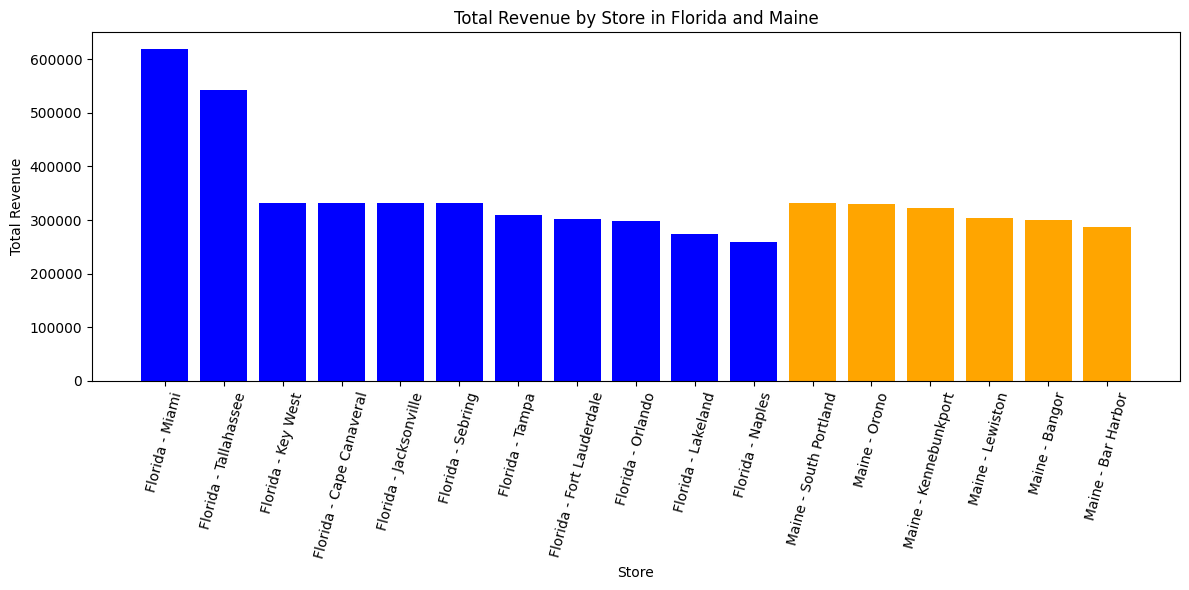

In [22]:
# plt.figure() = creates chart size.
# figsize=(12,6) = width and height of chart.
# copy() = creates a safe copy of DataFrame.
# + = joins text together.
# plt.bar() = creates a bar chart.
# plt.title() = adds chart title.
# plt.xlabel() = adds x-axis title.
# plt.ylabel() = adds y-axis title.
# plt.xticks(rotation=75) = rotates labels.
# plt.tight_layout() = prevents overlap.
# plt.show() = displays chart.

plt.figure(figsize=(12,6))
chart_data = (store_ranking.copy())
chart_data["Store Label"] = (
    chart_data["State"]
    + " - "
    + chart_data["Store Location"]
)

plt.bar(
    chart_data["Store Label"],
    chart_data["Total Revenue"],
    color=chart_data["State"].map({
        "Florida": "blue",
        "Maine": "orange"})
)

plt.title("Total Revenue by Store in Florida and Maine")

plt.xlabel( "Store")
plt.ylabel("Total Revenue")
plt.xticks( rotation=75)
plt.tight_layout()
plt.show()

### Chart Interpretation

This bar chart compares total revenue generated by stores in Florida and Maine. The x-axis represents store locations, while the y-axis represents total revenue.

The chart makes it easy to compare store performance because taller bars represent higher revenue. Florida stores are shown in blue and Maine stores are shown in orange to be readable. 

From the chart, some stores clearly generated more revenue than others, indicating stronger sales performance. This chart supports the store ranking analysis by visually showing which stores performed best in each territor

### Q 4
Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?
### logic
To answer this question, I will connect customer information with sales transactions using RewardsID and customer ID. After matching the records, I will calculate customer spending totals and rank customers by total purchases within Florida and Maine.

### What I Am Looking For
- Customer names and IDs  
- Total customer purchases  
- Customer rankings  
- Highest spending customers in each territory

### Prep customer data

In [14]:
# dropna() = removes rows with missing values.
# subset=["RewardsID"] =
# check missing values only in RewardsID column.
# copy() = creates safe copy.
# astype(int) = converts values into integers.
# merge() = combines two DataFrames.
# left_on= = matching column from left table.
# right_on= = matching column from right table.
# how="inner" = keeps matching rows only.
# sales_customers = merged customer sales table.

sales_customers = sales_with_store.dropna(
    subset=["RewardsID"]
).copy()
sales_customers["RewardsID"] = (
    sales_customers["RewardsID"]
    .astype(int)
)
df_customers["cust_id"] = (
   df_customers["cust_id"]
    .astype(int)
)
sales_customers = sales_customers.merge(
    df_customers,
    left_on="RewardsID",
    right_on="cust_id",
    how="inner"
)

sales_customers.head(3)

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Sales Month,Store Location,State,Territory Manager,Region,Region Director,cust_id,date,time,name,email,phone,sms-opt-out
0,2022-01-01,726,17,105381-M,55.00,2022-01-01,Orlando,Florida,Lana Ilana,South,Andy Gisselquist,17,2024-04-22,19:25:50,Mike E.,mike@lospolloshermanos.biz,505-555-2007,N
1,2022-01-01,821,507,105319-IT,30.16,2022-01-01,Lewiston,Maine,Erbayne Middleton,Northeast,Michael Jarvis,507,2024-01-16,11:19:45,Plankton,plankton@bikinibottom.net,555-555-3106,N
2,2022-01-01,822,491,105432-S,6.02,2022-01-01,Orono,Maine,Erbayne Middleton,Northeast,Michael Jarvis,491,2023-05-02,13:59:15,Harry Crane,harry@sterlingcooper.com,212-555-2910,N


### Ranking customer spendind

In [15]:
# groupby() = groups customer purchases together. ["State","cust_id","name"] = grouping columns.
# rename() = renames revenue column.
# groupby("State") = ranks customers inside each territory.
# ascending=False =
# highest spending customer gets Rank 1.
# sort_values() = sorts rows.
# head(20) = shows first 20 rows.


top_customers = sales_customers.groupby(
    ["State", "cust_id", "name"],
    as_index=False
)["Sale Amount"].sum()

top_customers = top_customers.rename(
    columns={"Sale Amount": "Total Customer Spending"}
)
top_customers["Rank"] = ( top_customers.groupby("State")
    ["Total Customer Spending"]
    .rank( method="dense",
           ascending=False)
    .astype(int)
)
top_customers = top_customers.sort_values(
    ["State", "Rank"]).reset_index(drop=True)

top_customers.head(2)

,State,cust_id,name,Total Customer Spending,Rank
0,Florida,47,Stanley H.,4954.99,1
1,Florida,259,Todd Chavez,4549.16,2


### Top customers

In [16]:
# Rank == 1 =
# keeps only highest spending customers.
# reset_index(drop=True) =
# fixes row numbering.

top_buyer = top_customers[
    top_customers["Rank"] == 1
].reset_index(drop=True)

top_buyer

,State,cust_id,name,Total Customer Spending,Rank
0,Florida,47,Stanley H.,4954.99,1
1,Maine,421,Rosita,3637.75,1


## Q5
What is the number of transactions per month by product category in each assigned territory?What is total sales revenue per month by category? What might this tell you about the mostpopular products, and where could there be opportunity for growth?

### Logic
To answer this question, I will connect the sales data with the product and product category data using the product number and category information. After matching the records, I will group the data by territory, sales month, and product category.

Then, I will calculate the number of transactions and total sales revenue for each category in Florida and Maine. This will help identify which categories perform best and which categories may need more marketing attention.

### What I Am Looking For
- Product categories sold in Florida and Maine
- Number of transactions per month by category
- Total sales revenue per month by category
- Most popular product categories
- Categories with lower sales that may provide growth opportunities

### Merge sales with products and categories

In [17]:
# how="left" = keeps all rows from the sales table.
# on=["CategoryID","SubcategoryID"] =
# matches using two columns.
# groupby() = groups rows together.
# agg() = calculates multiple summaries.
# Transactions=("Sale Amount","count") =
# counts how many sales happened.
# Total_Revenue=("Sale Amount","sum") = adds the sale amount.
# sort_values() = sorts the result.

sales_products = (
    sales_with_store.merge(df_products,
        on="Prod Num",
        how="left")
)
sales_products = (sales_products.merge(df_categories,
        on=["CategoryID","SubcategoryID"],
        how="left")
)
category_monthly = (
    sales_products.groupby(
        ["State","Sales Month","Category"],
        as_index=False
    )
    .agg(Num_of_Transactions=("Sale Amount", "count"),
        Total_Revenue=("Sale Amount", "sum")
    )
)
category_monthly = (
    category_monthly.sort_values(
        [ "State", "Sales Month", "Total_Revenue"],
        ascending=[True,True, False])
    .reset_index( drop=True)
)

category_monthly.head(3)

,State,Sales Month,Category,Num_of_Transactions,Total_Revenue
0,Florida,2022-01-01,Technology & Accessories,75,32658.69
1,Florida,2022-01-01,Textbooks,61,10287.31
2,Florida,2022-01-01,Art Supplies,80,2484.65


In [18]:

# groupby() = groups data by State and Category.
# agg() = performs more than one calculation.
# count = counts number of transactions.
# sum = adds total revenue.
# sort_values() = orders the results.
# reset_index(drop=True) =
# resets row numbers cleanly.

category_summary = (
    sales_products.groupby([ "State","Category"],
        as_index=False) 
        
    .agg(Num_of_Transactions=(
        "Sale Amount", "count"),
        Total_Revenue=("Sale Amount","sum"))
)

category_summary = (category_summary.sort_values(
        ["State", "Total_Revenue"],
        ascending=[True,False])
    .reset_index(drop=True)
)

category_summary.head(3)

,State,Category,Num_of_Transactions,Total_Revenue
0,Florida,Technology & Accessories,5934,2764161.11
1,Florida,Textbooks,4053,706789.57
2,Florida,Apparel and Merchandise,5539,180626.02


### What might this Tells you
- Technology & Accessories are the most popular and highest-earning products in both Florida and Maine.
- Textbooks also continue to be a strong category and remain an important part of the business.
- Marketing attention next quarter could focus on continuing to support strong categories while helping weaker categories grow customer interest and sales.

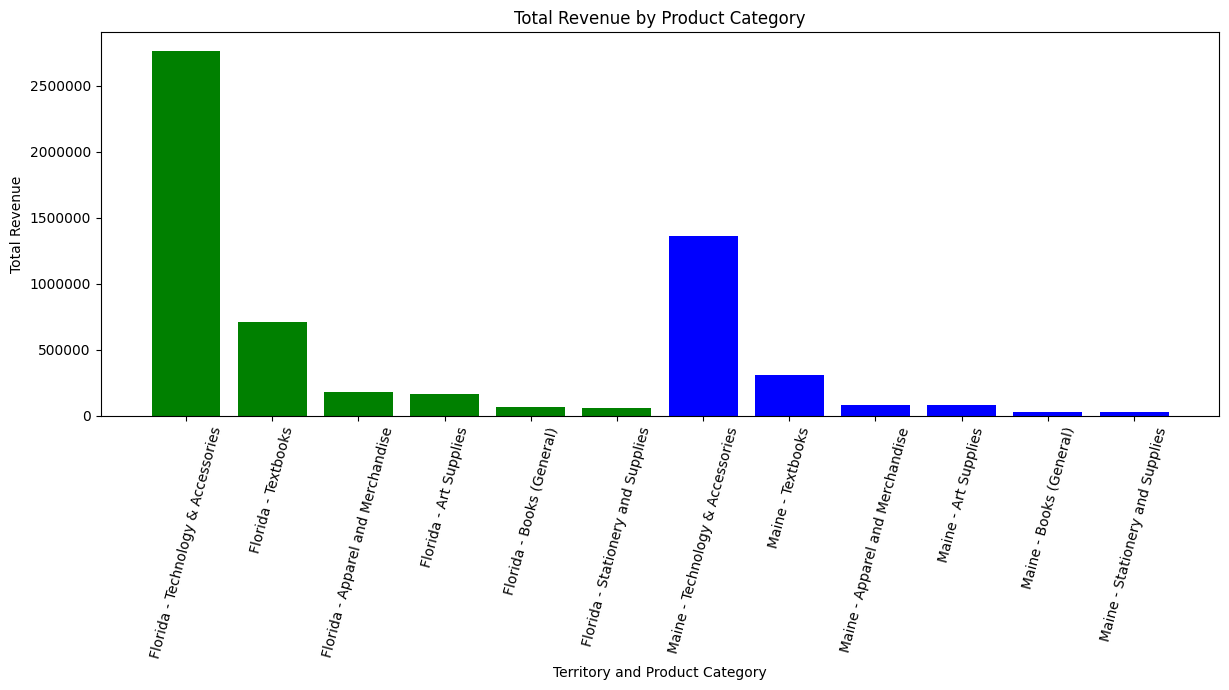

In [38]:
# copy() = creates a safe copy of the DataFrame.
# + = joins text together. 
# + " - " separate it with pace and a dash
# plt.bar() = creates a bar chart.
# plt.xticks(rotation=75) = rotates labels.
# plt.tight_layout() = prevents overlap.

plt.figure(figsize=(12,7))

category_chart = ( category_summary.copy())

category_chart["Label"] = (
    category_chart["State"]
    + " - "
    + category_chart["Category"]
)

plt.bar(
    category_chart["Label"],
    category_chart["Total_Revenue"],
    color=category_chart["State"].map({
        "Florida": "green",
        "Maine": "blue"})
)

plt.title("Total Revenue by Product Category")

plt.xlabel("Territory and Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=75)
plt.tight_layout()
plt.ticklabel_format(style="plain", axis="y")
plt.show()

### Chart Interpretation

Another bar chart comparing total revenue generated by product categories in Florida and Maine. The x-axis represents territory and product category, while the y-axis represents total revenue.

The chart makes it easy to compare which categories performed best because taller bars represent higher revenue. Florida categories are shown in green while Maine categories are shown in blue, making it easier to compare territory performance.

The highest bars identify the most profitable product categories, suggesting strong customer demand in those areas. Categories with shorter bars generated less revenue. This chart supports Question 5 by showing which categories contribute most to total sales and where growth opportunities may exist